In [2]:
# This bit is for big coupling maps which requires a stabilizer.
# 4x4 coupling map failed to run.

import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler import Target, CouplingMap
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate  # <-- Add this import
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

'''
# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)
'''

# Define parameters for the simulated backend
num_qubits = 16
basis_gates = ["id", "h", "x", "y", "z", "rz", "cx"]
p2 = 1e-2 # 2-qubit gate error probability
p1 = p2/10  # 1-qubit gate error probability
rz_angle = np.pi / 2  # Match initial_entangling_angle

shots = 10000
lengths = [2]+[4,10,20,50,100]
num_samples = 20
 
cmap = CouplingMap.from_grid(4, 4, bidirectional=True)

# Create a Target object to define the gates, including rz explicitly
target = Target.from_configuration(
    num_qubits=num_qubits,
    basis_gates=basis_gates,
    coupling_map=cmap,
    custom_name_mapping={
        "id": Operator(np.array([[1, 0], [0, 1]])).to_instruction(),  # Identity gate
        "h": Operator(np.array([[1, 1], [1, -1]]) / np.sqrt(2)).to_instruction(),  # Hadamard gate
        "x": Operator(np.array([[0, 1], [1, 0]])).to_instruction(),  # Pauli X gate
        "y": Operator(np.array([[0, -1j], [1j, 0]])).to_instruction(),  # Pauli Y gate
        "z": Operator(np.array([[1, 0], [0, -1]])).to_instruction(),  # Pauli Z gate
        "rz": Operator([[np.cos(rz_angle / 2), -1j*np.sin(rz_angle / 2)],
                        [-1j*np.sin(rz_angle / 2), np.cos(rz_angle / 2)]]).to_instruction(),  # RZ(π/2)
        # Use the built-in CXGate to ensure a valid Qiskit Instruction is used for two-qubit gates
        "cx": CXGate(),  # CNOT gate
    }
)

# Create a noise model to emulate the NoisyBackend
noise_model = NoiseModel()

# Add depolarizing errors for 1-qubit and 2-qubit gates
error_1q = depolarizing_error(p1, 1)
error_2q = depolarizing_error(p2, 2)

# Apply errors to all basis gates except 'delay' and 'reset'
for gate in basis_gates:
    if gate in ["id", "h", "x", "y", "z", "rz"]:
        noise_model.add_all_qubit_quantum_error(error_1q, gate)
    elif gate == "cx":
        noise_model.add_all_qubit_quantum_error(error_2q, gate)

# Set up the AerSimulator with stabilizer method, target, and noise model
backend = AerSimulator(
    method="stabilizer",
    noise_model=noise_model if (p1 > 0 or p2 > 0) else None,
    target=target,
    max_parallel_threads=0,
    max_parallel_experiments=0,
    # seed_simulator=SEED
)

# Set up the experiment object
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25, # aim for 1.0 and 0.5 for mirror_qa_topo (0.25 from Fez)
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    sampling_algorithm='new', # 'edge_grab', 'matching'
    # seed=SEED
    # pauli_randomiza=True, # True by default
)

# Set run options
exp.set_run_options(shots=shots)

rb_data = exp.run()
print(rb_data.job_ids)

for i in range(20):
    print(f"Pairs from round {i}", exp._pairs[i])

[DEBUG] Layer 0: qargs=(0,), type=<class 'numpy.int64'>, repr=np.int64(6)
[DEBUG] Layer 0: qargs=(1,), type=<class 'numpy.int64'>, repr=np.int64(21)
[DEBUG] Layer 0: qargs=(2,), type=<class 'numpy.int64'>, repr=np.int64(19)
[DEBUG] Layer 0: qargs=(3,), type=<class 'numpy.int64'>, repr=np.int64(19)
[DEBUG] Layer 0: qargs=(4,), type=<class 'numpy.int64'>, repr=np.int64(17)
[DEBUG] Layer 0: qargs=(5,), type=<class 'numpy.int64'>, repr=np.int64(9)
[DEBUG] Layer 0: qargs=(6,), type=<class 'numpy.int64'>, repr=np.int64(23)
[DEBUG] Layer 0: qargs=(7,), type=<class 'numpy.int64'>, repr=np.int64(5)
[DEBUG] Layer 0: qargs=(8,), type=<class 'numpy.int64'>, repr=np.int64(15)
[DEBUG] Layer 0: qargs=(9,), type=<class 'numpy.int64'>, repr=np.int64(18)
[DEBUG] Layer 0: qargs=(10,), type=<class 'numpy.int64'>, repr=np.int64(16)
[DEBUG] Layer 0: qargs=(11,), type=<class 'numpy.int64'>, repr=np.int64(0)
[DEBUG] Layer 0: qargs=(12,), type=<class 'numpy.int64'>, repr=np.int64(19)
[DEBUG] Layer 0: qargs=(13

In [3]:
# *** It's stuck here ***
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
# exp.analysis.set_options(analyzed_quantity='Mutual Information')

In [ ]:
exp._static_trans_circuits[0].draw(fold=-1)

In [4]:
analysis = exp.analysis.run(rb_data)

In [5]:
# job id: '4d59ce51-72cc-4f0e-99ed-c2ee2e907ffa' (from Tue 9 Feb 09:20)
print(rb_data)

---------------------------------------------------
Experiment: MirrorQA
Experiment ID: f5319610-9bca-4f5e-8fb6-e5451d00aa28
Status: ExperimentStatus.DONE
Backend: AerSimulator('aer_simulator_stabilizer'
             noise_model=<NoiseModel on ['h', 'z', 'x', 'cx', 'id', 'y', 'rz']>)
Data: 120
Analysis Results: 3
Figures: 1
Artifacts: 2


In [6]:
print(exp.analysis)

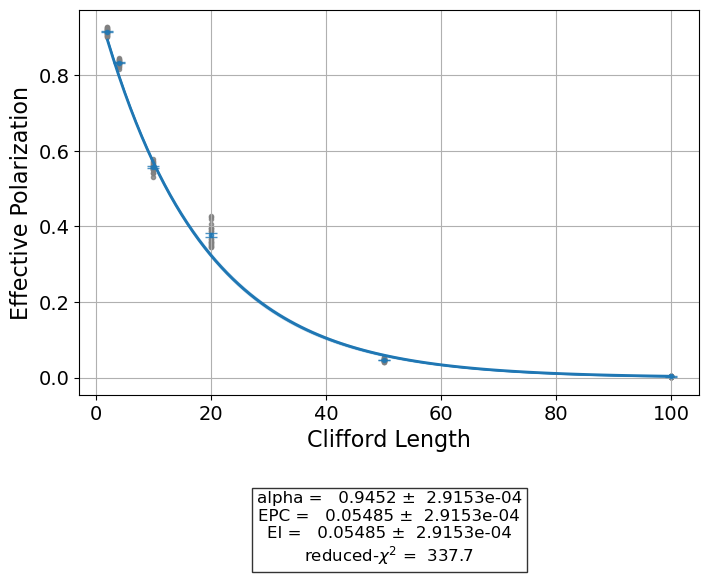

In [8]:
analysis.figure(0)

In [9]:
qa = QuantumAwesomeness(exp.backend.coupling_map)

/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype

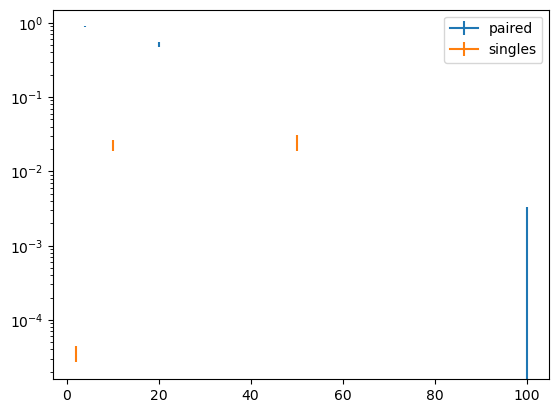

In [10]:
mi = qa.mutual_info(rb_data.data())

mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % 6].append(m)
    for j in range(6):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

In [ ]:
exp._static_trans_circuits[0].draw(fold=-1)